# 4. The Quest - S&P 500 Stocks Prediction
---
Q2 (ML/DL regression): predpovedajte nastávajúcu situáciu podľa historických dát 4.1

## 4.1 EDA and data preprocessing 	(5b) 
- (A-4b) EDA a data preprocessing pre Vami vybrané charakteristiky z datasetu 
- (B-1b) Zdôvodnite výber ML/DL metód vzhľadom na Vami vybraný dataset pre 4.2
## 4.2 Modeling and evaluation (5b)
- (A-4b) Modeluje Vami tie vybrané charakteristiky pomocou vhodných ML/DL metód. Výsledok modelovania je najlepší model.
- (B-1b) Zhodnotíte Váš prístup a získaný výsledok


# 4.1 EDA and data preprocessing

In [ ]:
import kagglehub
import pandas as pd
import os

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-whitegrid')

from sklearn.preprocessing import PowerTransformer, RobustScaler

import numpy as np

## Načítanie dát

In [152]:
# Download latest version
path = kagglehub.dataset_download("andrewmvd/sp-500-stocks")

print("Path to dataset files:", path)
os.listdir(path)

Path to dataset files: C:\Users\ap\.cache\kagglehub\datasets\andrewmvd\sp-500-stocks\versions\1023


['sp500_companies.csv', 'sp500_index.csv', 'sp500_stocks.csv']

In [153]:
df_stocks = pd.read_csv(f"{path}/sp500_stocks.csv")
df_companies = pd.read_csv(f"{path}/sp500_companies.csv")
df_index = pd.read_csv(f"{path}/sp500_index.csv")

### Dataset Stocks
Dataset ``df_stocks`` obsahuje historické dáta o cenách akcií jednotlivých spoločností vrátane otvorenia, zatvorenia, maxima, minima a objemu obchodov pre každý deň. Obsahuje každodenné záznamy od 2010 do 2024 pre viac ako 500 spoločností. Tym, ze ide o kazdodenne data, tak obsahuje vela chybajucich hodnot, pretoze nie kazda akcia bola obchodovana kazdy den.

In [154]:
df_stocks.shape

(1891536, 8)

In [155]:
df_stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891536 entries, 0 to 1891535
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date       object 
 1   Symbol     object 
 2   Adj Close  float64
 3   Close      float64
 4   High       float64
 5   Low        float64
 6   Open       float64
 7   Volume     float64
dtypes: float64(6), object(2)
memory usage: 115.5+ MB


In [156]:
df_stocks.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,MMM,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,MMM,NaN,NaN,NaN,NaN,NaN,NaN


In [157]:
df_stocks.isnull().sum()

Date               0
Symbol             0
Adj Close    1273705
Close        1273705
High         1273705
Low          1273705
Open         1273705
Volume       1273705
dtype: int64

In [158]:
df_stocks.nunique()

Date           3768
Symbol          502
Adj Close    525360
Close        123637
High         123036
Low          122480
Open         121187
Volume       208513
dtype: int64

In [159]:
df_stocks.describe()

,Adj Close,Close,High,Low,Open,Volume
count,617831.000000,617831.000000,617831.000000,617831.000000,617831.000000,6.178310e+05
mean,79.672357,87.471540,88.417844,86.480997,87.460302,9.347125e+06
std,102.742931,104.521901,105.684113,103.300770,104.519845,4.771669e+07
min,0.203593,0.222000,0.226250,0.216250,0.218000,0.000000e+00
25%,26.572459,32.700001,33.060001,32.299999,32.689999,1.144000e+06
50%,49.821613,59.139999,59.720001,58.500000,59.119999,2.453400e+06
75%,94.831036,105.019997,106.129997,103.889999,105.000000,5.657850e+06
max,1702.530029,1702.530029,1714.750000,1696.900024,1706.400024,3.692928e+09


### Dataset Companies
Dataset ``df_companies`` obsahuje informácie o spoločnostiach zahrnutých v indexe S&P 500, vrátane ich symbolov, názvov, sektorov, odvetví a trhovej kapitalizácie.

In [160]:
df_companies.shape

(502, 16)

In [161]:
df_companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Exchange             502 non-null    object 
 1   Symbol               502 non-null    object 
 2   Shortname            502 non-null    object 
 3   Longname             502 non-null    object 
 4   Sector               502 non-null    object 
 5   Industry             502 non-null    object 
 6   Currentprice         502 non-null    float64
 7   Marketcap            502 non-null    int64  
 8   Ebitda               473 non-null    float64
 9   Revenuegrowth        499 non-null    float64
 10  City                 502 non-null    object 
 11  State                482 non-null    object 
 12  Country              502 non-null    object 
 13  Fulltimeemployees    493 non-null    float64
 14  Longbusinesssummary  502 non-null    object 
 15  Weight               502 non-null    flo

In [162]:
df_companies.head()

,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.115830e+11,0.110,Seattle,WA,United States,1551000.0,"Amazon.com, Inc. engages in the retail sale of...",0.042550
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.234700e+11,0.151,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.042309


In [163]:
df_companies.isnull().sum()

Exchange                0
Symbol                  0
Shortname               0
Longname                0
Sector                  0
Industry                0
Currentprice            0
Marketcap               0
Ebitda                 29
Revenuegrowth           3
City                    0
State                  20
Country                 0
Fulltimeemployees       9
Longbusinesssummary     0
Weight                  0
dtype: int64

In [164]:
df_companies.nunique()

Exchange                 4
Symbol                 502
Shortname              499
Longname               499
Sector                  11
Industry               114
Currentprice           499
Marketcap              502
Ebitda                 469
Revenuegrowth          260
City                   235
State                   41
Country                  8
Fulltimeemployees      387
Longbusinesssummary    499
Weight                 502
dtype: int64

In [165]:
df_companies.describe()

,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Weight
count,502.000000,5.020000e+02,4.730000e+02,499.000000,4.930000e+02,502.000000
mean,217.893685,1.107222e+11,7.045286e+09,0.070541,5.782761e+04,0.001992
std,489.205027,3.440074e+11,1.624213e+10,0.180247,1.395988e+05,0.006189
min,9.400000,4.664099e+09,-3.991000e+09,-0.602000,2.800000e+01,0.000084
25%,68.547500,1.933417e+10,1.625000e+09,0.002000,1.020000e+04,0.000348
50%,118.365000,3.706396e+10,2.952748e+09,0.051000,2.169000e+04,0.000667
75%,227.667500,7.830565e+10,6.020000e+09,0.109000,5.510000e+04,0.001409
max,8276.780000,3.846820e+12,1.495470e+11,1.632000,2.100000e+06,0.069209


### Dataset Index
Dataset ``df_index`` obsahuje historické hodnoty indexu S&P 500, ktorý predstavuje celkový výkon trhu -> to znamena, ze zahrna **vplyv celeho trhu na jednotlive akcie**. Obsahuje denné záznamy od 2014 do 2024.

In [166]:
df_index.shape

(2517, 2)

In [167]:
df_index.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2517 non-null   object 
 1   S&P500  2517 non-null   float64
dtypes: float64(1), object(1)
memory usage: 39.5+ KB


In [168]:
df_index.head()

,Date,S&P500
0,2014-12-22,2078.54
1,2014-12-23,2082.17
2,2014-12-24,2081.88
3,2014-12-26,2088.77
4,2014-12-29,2090.57


In [169]:
df_index.isnull().sum()

Date      0
S&P500    0
dtype: int64

In [170]:
df_index.nunique()

Date      2517
S&P500    2505
dtype: int64

In [171]:
df_index.describe()

,S&P500
count,2517.000000
mean,3346.351605
std,1078.204274
min,1829.080000
25%,2428.370000
50%,2999.910000
75%,4199.120000
max,6090.270000


## EDA a data preprocessing

### EDA

#### Analyza null hodnot

V datasete ``df_stocks`` sa nachadza najviac chybajúcich hodnot, okrem stlpcov ``Date`` a ``Symbol``, v kazdom chyba 67.67% hodnot, co su vlastne kazdodenne data, pretoze nie kazda akcia bola obchodovana kazdy den. Tieto stlpce sme neskôr odstranili vyberom akcii s kompletnymi datami.

V datasete ``df_companies`` sa nachadza len par chybajucich hodnot v stlpcoch ``Sector``, ``Industry`` a ``Marketcap``, co moze byt sposobene tym, ze niektore firmy nemusia mat priradeny sektor alebo industry (napr. nove firmy).

V datasete ``df_index`` sa nenachadzaju ziadne chybajuce hodnoty.

In [172]:
# df_stocks
print("\ndf_stocks:")
print(f"   Shape: {df_stocks.shape}")
null_stocks = df_stocks.isnull().sum()
null_pct = (null_stocks / len(df_stocks) * 100).round(2)
print(pd.DataFrame({'Null Count': null_stocks, 'Null %': null_pct}))

# df_companies
print("\ndf_companies:")
print(f"   Shape: {df_companies.shape}")
null_companies = df_companies.isnull().sum()
null_pct_comp = (null_companies / len(df_companies) * 100).round(2)
print(pd.DataFrame({'Null Count': null_companies, 'Null %': null_pct_comp})[null_companies > 0])

# df_index
print("\ndf_index:")
print(f"   Shape: {df_index.shape}")
print(df_index.isnull().sum())


df_stocks:
   Shape: (1891536, 8)
           Null Count  Null %
Date                0    0.00
Symbol              0    0.00
Adj Close     1273705   67.34
Close         1273705   67.34
High          1273705   67.34
Low           1273705   67.34
Open          1273705   67.34
Volume        1273705   67.34

df_companies:
   Shape: (502, 16)
                   Null Count  Null %
Ebitda                     29    5.78
Revenuegrowth               3    0.60
State                      20    3.98
Fulltimeemployees           9    1.79

df_index:
   Shape: (2517, 2)
Date      0
S&P500    0
dtype: int64


#### Kontrola dátových typov
Ide primárne o číselné dáta (float64/int64) a dátumy (`object` sme zmenili na `datetime`). Stlpce Symbol, Shortname, Sector, Industry su typu object (string).

In [173]:
# Kontrola dátových typov
print("\ndf_stocks:")
print(df_stocks.dtypes)

print("\ndf_companies:")
print(df_companies.dtypes)

print("\ndf_index:")
print(df_index.dtypes)


df_stocks:
Date          object
Symbol        object
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume       float64
dtype: object

df_companies:
Exchange                object
Symbol                  object
Shortname               object
Longname                object
Sector                  object
Industry                object
Currentprice           float64
Marketcap                int64
Ebitda                 float64
Revenuegrowth          float64
City                    object
State                   object
Country                 object
Fulltimeemployees      float64
Longbusinesssummary     object
Weight                 float64
dtype: object

df_index:
Date       object
S&P500    float64
dtype: object


#### Konverzia dátumov

In [174]:
df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])
df_index['Date'] = pd.to_datetime(df_index['Date'])

#### Kontrola duplikátov
Duplicitné údaje neboli nájdené v žiadnom z datasetov.

In [175]:
dup_stocks = df_stocks.duplicated(subset=['Date', 'Symbol']).sum()
print(f"df_stocks duplicity: {dup_stocks}")

dup_companies = df_companies.duplicated(subset=['Symbol']).sum()
print(f"df_companies duplicity: {dup_companies}")

dup_index = df_index.duplicated(subset=['Date']).sum()
print(f"df_index duplicity: {dup_index}")

df_stocks duplicity: 0
df_companies duplicity: 0
df_index duplicity: 0


#### Casovy rozsah datasetov
Dataset ``df_stocks`` obsahuje dáta od 04.01.2010 do 20.12.2024, zatiaľ čo dataset ``df_index`` obsahuje dáta od 22.12.2014 do 20.12.2024
. Pre účely modelovania budeme pracovať s dátami od **22.12.2014**, aby sme mali konzistentný časový rozsah.

In [176]:
print("Časový rozsah dát:")
print(f"  df_stocks: od {df_stocks['Date'].min()} do {df_stocks['Date'].max()}")
print(f"  df_index:  od {df_index['Date'].min()} do {df_index['Date'].max()}")

Časový rozsah dát:
  df_stocks: od 2010-01-04 00:00:00 do 2024-12-20 00:00:00
  df_index:  od 2014-12-22 00:00:00 do 2024-12-20 00:00:00


#### Unikátne akcie v df_stocks
K dispozicii máme dáta pre **502** unikátnych akcií.

In [177]:
print(f"\nPočet unikátnych akcií: {df_stocks['Symbol'].nunique()}")


Počet unikátnych akcií: 502


#### NaN hodnoty v df_stocks
V datasete ``df_stocks`` sa nachadaza najviac chybajúcich hodnot, okrem stlpcov ``Date`` a ``Symbol``, v kazdom chyba 67.67% hodnot. Tieto stlpce vsak nebudeme pouzivat pre modelovanie, kedze ide iba o casove udaje. Preto sa zameriame na vybratie akcii s kompletnymi dátami (bez NaN hodnôt) pre stĺpec ``Close``, ktorý je kľúčový pre analýzu a modelovanie.

In [178]:
print('Percentage of missing values in each column:')
print(df_stocks.isnull().sum()/len(df_stocks)*100)

Percentage of missing values in each column:
Date          0.000000
Symbol        0.000000
Adj Close    67.337074
Close        67.337074
High         67.337074
Low          67.337074
Open         67.337074
Volume       67.337074
dtype: float64


Pre jednotlivé akcie vypočítame počet riadkov a počet platných (non-NaN) hodnôt v stĺpci ``Close`` a zistíme časový rozsah dát pre každú akciu.

In [179]:
stock_completeness = df_stocks.groupby('Symbol').agg(
    Total_Rows=('Close', 'count'),
    Valid_Rows=('Close', lambda x: x.notna().sum()),
    Date_Min=('Date', 'min'),
    Date_Max=('Date', 'max')
).reset_index()

stock_completeness.head()

,Symbol,Total_Rows,Valid_Rows,Date_Min,Date_Max
0,A,0,0,2010-01-04,2024-12-20
1,AAPL,0,0,2010-01-04,2024-12-20
2,ABBV,3014,3014,2010-01-04,2024-12-20
3,ABNB,0,0,2010-01-04,2024-12-20
4,ABT,3768,3768,2010-01-04,2024-12-20


In [180]:
stock_completeness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Symbol      502 non-null    object        
 1   Total_Rows  502 non-null    int64         
 2   Valid_Rows  502 non-null    int64         
 3   Date_Min    502 non-null    datetime64[ns]
 4   Date_Max    502 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(1)
memory usage: 19.7+ KB


#### Výber akcií s kompletnými dátami

In [181]:
complete_stocks = stock_completeness[stock_completeness['Valid_Rows'] == 3768]['Symbol'].tolist()
print(f"Počet akcií s kompletnými dátami: {len(complete_stocks)}")

Počet akcií s kompletnými dátami: 150


Po vybraní akcií s ``valid_rows`` (kompletnymi dátami) nám zostalo **150** akcií.

In [182]:
df_stocks_clean = df_stocks[df_stocks['Symbol'].isin(complete_stocks)].copy()
df_stocks_clean = df_stocks_clean.dropna(subset=['Close'])
df_stocks_clean.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
3768,2010-01-04,AOS,5.937266,7.435000,7.480000,7.261667,7.295000,1104600.0
3769,2010-01-05,AOS,5.861404,7.340000,7.431667,7.308333,7.431667,1207200.0
3770,2010-01-06,AOS,5.864068,7.343333,7.405000,7.301667,7.335000,663000.0
3771,2010-01-07,AOS,5.881369,7.365000,7.425000,7.311667,7.356667,564000.0
3772,2010-01-08,AOS,5.967879,7.473333,7.485000,7.311667,7.331667,504600.0


### Spojenie datasetov

In [183]:
# spojenie s df_companies, aby sme pridali informácie o spoločnostiach
df_merged = df_stocks_clean.merge(
    df_companies[['Symbol', 'Shortname', 'Sector', 'Industry', 'Marketcap']],
    on='Symbol',
    how='left'
)

# následne spojenie s df_index
df_stocks_final = df_merged.merge(
    df_index.rename(columns={'S&P500': 'SP500_Index'}),
    on='Date',
    how='inner'  # použijeme INNER JOIN aby sme mali len obdobie 2014+
)

In [184]:
print(f"\nVÝSLEDNÝ DATASET")
print('*' * 70)

print(f"Shape: {df_stocks_final.shape}")
print(f"Časový rozsah: {df_stocks_final['Date'].min()} až {df_stocks_final['Date'].max()}")
print(f"Počet akcií: {df_stocks_final['Symbol'].nunique()}")
print(f"NaN hodnoty: {df_stocks_final.isnull().sum().sum()}")


VÝSLEDNÝ DATASET
**********************************************************************
Shape: (377550, 13)
Časový rozsah: 2014-12-22 00:00:00 až 2024-12-20 00:00:00
Počet akcií: 150
NaN hodnoty: 0


In [185]:
df_stocks_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377550 entries, 0 to 377549
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Date         377550 non-null  datetime64[ns]
 1   Symbol       377550 non-null  object        
 2   Adj Close    377550 non-null  float64       
 3   Close        377550 non-null  float64       
 4   High         377550 non-null  float64       
 5   Low          377550 non-null  float64       
 6   Open         377550 non-null  float64       
 7   Volume       377550 non-null  float64       
 8   Shortname    377550 non-null  object        
 9   Sector       377550 non-null  object        
 10  Industry     377550 non-null  object        
 11  Marketcap    377550 non-null  int64         
 12  SP500_Index  377550 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(4)
memory usage: 37.4+ MB


In [186]:
df_stocks_final.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume,Shortname,Sector,Industry,Marketcap,SP500_Index
0,2014-12-22,AOS,23.673809,27.674999,27.684999,27.200001,27.309999,852600.0,A.O. Smith Corporation,Industrials,Specialty Industrial Machinery,9964057600,2078.54
1,2014-12-23,AOS,23.960384,28.010000,28.145000,27.590000,27.795000,973400.0,A.O. Smith Corporation,Industrials,Specialty Industrial Machinery,9964057600,2082.17
2,2014-12-24,AOS,24.033092,28.094999,28.209999,27.900000,27.900000,233600.0,A.O. Smith Corporation,Industrials,Specialty Industrial Machinery,9964057600,2081.88
3,2014-12-26,AOS,24.217010,28.309999,28.455000,28.170000,28.250000,360000.0,A.O. Smith Corporation,Industrials,Specialty Industrial Machinery,9964057600,2088.77
4,2014-12-29,AOS,24.238392,28.334999,28.490000,28.195000,28.299999,391800.0,A.O. Smith Corporation,Industrials,Specialty Industrial Machinery,9964057600,2090.57


#### Kontrola spojeného datasetu

In [187]:
print("KONTROLA PO SPOJENÍ")
print('*' * 50)

# NaN hodnoty
print("\nNaN hodnoty po stĺpcoch:")
print(df_stocks_final.isnull().sum())

# Duplicity
duplicates = df_stocks_final.duplicated(subset=['Date', 'Symbol']).sum()
print(f"\nDuplicity (Date + Symbol): {duplicates}")

KONTROLA PO SPOJENÍ
**************************************************

NaN hodnoty po stĺpcoch:
Date           0
Symbol         0
Adj Close      0
Close          0
High           0
Low            0
Open           0
Volume         0
Shortname      0
Sector         0
Industry       0
Marketcap      0
SP500_Index    0
dtype: int64

Duplicity (Date + Symbol): 0


### Základné štatistiky

#### Výber akcií s kompletnými dátami
Statistiky pre numerické stĺpce vrátane Mean, Median a Ratio.

Ratio = Mean / Median (ak je ratio > 1.5, tak to indikuje prítomnosť outlierov)

V nasom pripade je Ratio pre `Close = 1.43` a pre `Volume = 3.59` -> teda Close nemá výrazné outliery, ale Volume áno

In [188]:
print(df_stocks_final[['Open', 'High', 'Low', 'Close', 'Volume', 'SP500_Index']].describe())

# Mean vs Median
stats = pd.DataFrame({
    'Mean': df_stocks_final[['Close', 'Volume']].mean(),
    'Median': df_stocks_final[['Close', 'Volume']].median(),
})
stats['Ratio'] = stats['Mean'] / stats['Median']
print("\nMean vs Median:")
print(stats)

                Open           High            Low          Close  \
count  377550.000000  377550.000000  377550.000000  377550.000000   
mean      109.971668     111.172469     108.738006     109.980578   
std       122.561463     123.916176     121.137703     122.564104   
min         0.481250       0.487500       0.473500       0.478500   
25%        45.419998      45.930000      44.924430      45.430000   
50%        76.760002      77.570000      75.940002      76.760002   
75%       131.070007     132.500000     129.629169     131.089996   
max      1706.400024    1714.750000    1696.900024    1702.530029   

             Volume    SP500_Index  
count  3.775500e+05  377550.000000  
mean   8.169377e+06    3346.351605  
std    4.413884e+07    1077.991495  
min    0.000000e+00    1829.080000  
25%    1.126254e+06    2428.370000  
50%    2.274300e+06    2999.910000  
75%    4.998000e+06    4199.120000  
max    3.692928e+09    6090.270000  

Mean vs Median:
                Mean        

In [189]:
df_stocks_final = df_stocks_final.sort_values(['Symbol', 'Date'])
df_stocks_final['Daily_Return'] = df_stocks_final.groupby('Symbol')['Close'].pct_change()

print(f"NaN v Daily_Return (prvý deň každej akcie): {df_stocks_final['Daily_Return'].isna().sum()}")

NaN v Daily_Return (prvý deň každej akcie): 150


## Vizualizácie

### Top 5 najlepsich vs Top 5 najhosich akcií podľa celkového výnosu (2014-2024)

In [190]:
# Výpočet celkového výnosu
df_sorted = df_stocks_final.sort_values('Date')
first_last = df_sorted.groupby('Symbol')['Close'].agg(['first', 'last'])
total_returns = ((first_last['last'] / first_last['first'] - 1) * 100).sort_values(ascending=False)

top5_best = total_returns.head(5).index.tolist()
top5_worst = total_returns.tail(5).index.tolist()

print(f"Top 5 best: {top5_best}")
print(f"Top 5 worst: {top5_worst}")

Top 5 best: ['NVDA', 'AXON', 'BLDR', 'NFLX', 'FTNT']
Top 5 worst: ['CCL', 'WDC', 'BEN', 'VTRS', 'PARA']


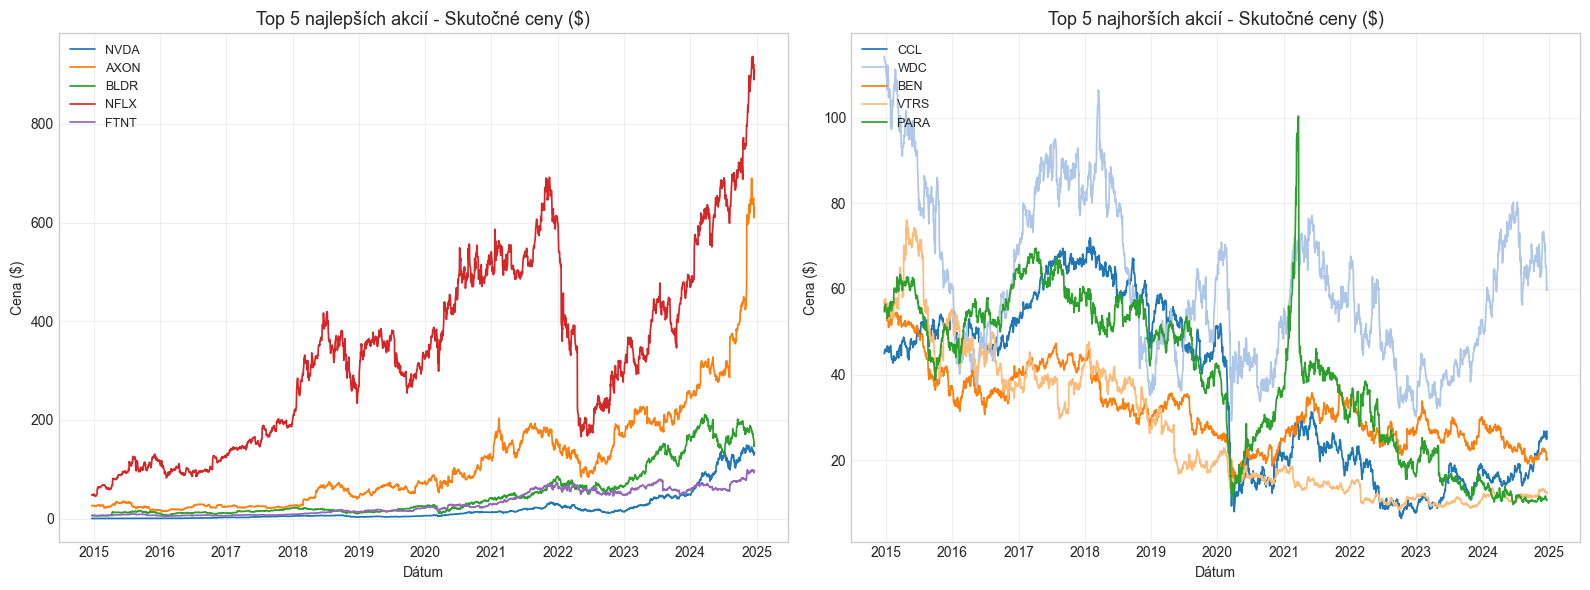

In [191]:
# python
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# palettes (choose large enough palettes for uniqueness)
cmap_best = plt.get_cmap('tab10')
cmap_worst = plt.get_cmap('tab20')

# Top 5 best - distinct colors
for i, symbol in enumerate(top5_best):
    stock_data = df_stocks_final[df_stocks_final['Symbol'] == symbol].sort_values('Date')
    color = cmap_best(i % cmap_best.N)
    axes[0].plot(stock_data['Date'], stock_data['Close'], label=symbol, color=color, linewidth=1.25)

axes[0].set_title('Top 5 najlepších akcií - Skutočné ceny ($)', fontsize=13)
axes[0].set_xlabel('Dátum')
axes[0].set_ylabel('Cena ($)')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Top 5 worst - distinct colors
for i, symbol in enumerate(top5_worst):
    stock_data = df_stocks_final[df_stocks_final['Symbol'] == symbol].sort_values('Date')
    color = cmap_worst(i % cmap_worst.N)
    axes[1].plot(stock_data['Date'], stock_data['Close'], label=symbol, color=color, linewidth=1.25)

axes[1].set_title('Top 5 najhorších akcií - Skutočné ceny ($)', fontsize=13)
axes[1].set_xlabel('Dátum')
axes[1].set_ylabel('Cena ($)')
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

skutočné cenové grafy -> zobrazené sú reálne ceny akcií v dolároch za dané obdobie

### Analýza podľa sektorov
Z grafov nám vyplyva, ze sektory ako Financials Services, Industrials a Technology mali v tomto obdobi najviac firiem s pozitivnym vyvojom. Naopak sektory ako Energy a Utilities mali viac firiem s negativnym vyvojom.

Volalita je najvyssia v sektoroch Energy a Technology, co moze byt sposobene vysokou konkurenciou a rychlymi zmenami v tychto odvetviach.


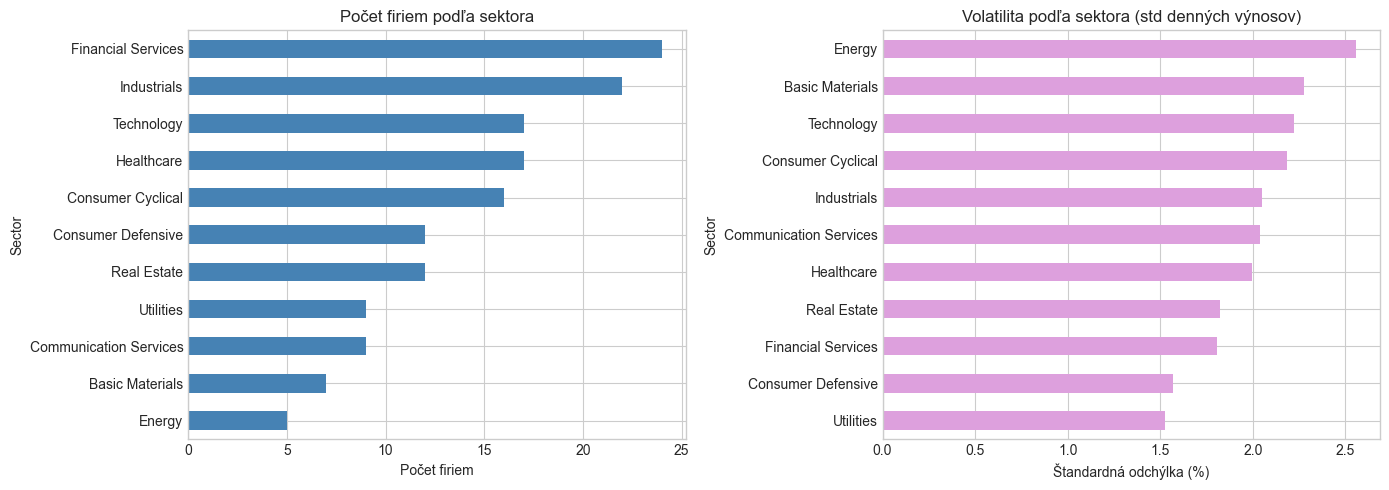


Volatilita podľa sektora:
Sector
Utilities                 1.526
Consumer Defensive        1.568
Financial Services        1.808
Real Estate               1.823
Healthcare                1.993
Communication Services    2.040
Industrials               2.049
Consumer Cyclical         2.182
Technology                2.225
Basic Materials           2.278
Energy                    2.559
Name: Daily_Return, dtype: float64


In [192]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Počet firiem podľa sektora
sector_counts = df_stocks_final.groupby('Sector')['Symbol'].nunique().sort_values(ascending=True)
sector_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Počet firiem podľa sektora')
axes[0].set_xlabel('Počet firiem')

# Priemerná volatilita podľa sektora
sector_volatility = df_stocks_final.groupby('Sector')['Daily_Return'].std().sort_values(ascending=True) * 100
sector_volatility.plot(kind='barh', ax=axes[1], color='plum')
axes[1].set_title('Volatilita podľa sektora (std denných výnosov)')
axes[1].set_xlabel('Štandardná odchýlka (%)')

plt.tight_layout()
plt.show()

print("\nVolatilita podľa sektora:")
print(sector_volatility.round(3))

### Box ploty denných výnosov podľa rokov a sektorov

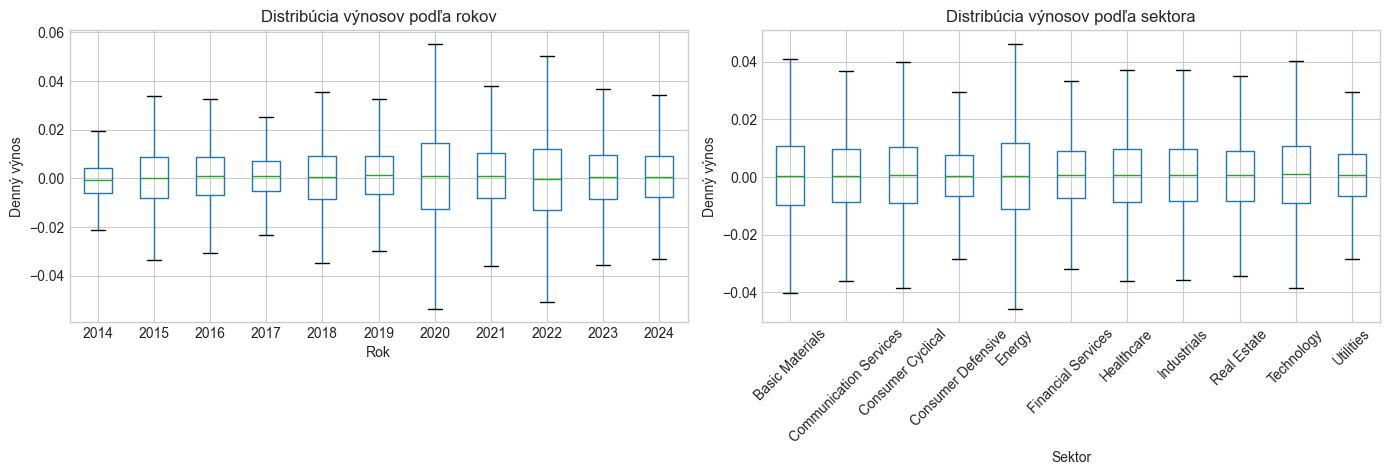

In [193]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot podľa rokov
df_stocks_final['Year'] = df_stocks_final['Date'].dt.year
df_stocks_final.boxplot(column='Daily_Return', by='Year', ax=axes[0], showfliers=False)
axes[0].set_title('Distribúcia výnosov podľa rokov')
axes[0].set_xlabel('Rok')
axes[0].set_ylabel('Denný výnos')
plt.suptitle('')

# Box plot podľa sektora
df_stocks_final.boxplot(column='Daily_Return', by='Sector', ax=axes[1], showfliers=False, rot=45)
axes[1].set_title('Distribúcia výnosov podľa sektora')
axes[1].set_xlabel('Sektor')
axes[1].set_ylabel('Denný výnos')
plt.suptitle('')

plt.tight_layout()
plt.show()

#### Extrémne výnosy (outliers)

In [194]:
print("="*60)
print("EXTRÉMNE VÝNOSY (OUTLIERS)")
print("="*60)

# Najväčšie prepady
print("\nTop 10 najväčších jednodňových prepadov:")
worst_days = df_stocks_final.nsmallest(10, 'Daily_Return')[['Date', 'Symbol', 'Sector', 'Close', 'Daily_Return']]
worst_days['Return_%'] = (worst_days['Daily_Return'] * 100).round(2)
print(worst_days.to_string(index=False))

# Najväčšie nárasty
print("\nTop 10 najväčších jednodňových nárastov:")
best_days = df_stocks_final.nlargest(10, 'Daily_Return')[['Date', 'Symbol', 'Sector', 'Close', 'Daily_Return']]
best_days['Return_%'] = (best_days['Daily_Return'] * 100).round(2)
print(best_days.to_string(index=False))

EXTRÉMNE VÝNOSY (OUTLIERS)

Top 10 najväčších jednodňových prepadov:
      Date Symbol                 Sector      Close  Daily_Return  Return_%
2024-07-26   DXCM             Healthcare  64.000000     -0.406583    -40.66
2017-07-05    BKR                 Energy  37.250000     -0.354196    -35.42
2022-04-20   NFLX Communication Services 226.190002     -0.351166    -35.12
2016-02-08    WMB                 Energy  11.160000     -0.348131    -34.81
2020-04-01    CCL      Consumer Cyclical   8.800000     -0.331815    -33.18
2017-09-28   DXCM             Healthcare  11.360000     -0.326516    -32.65
2024-08-29     DG     Consumer Defensive  84.029999     -0.321463    -32.15
2020-03-12    CCL      Consumer Cyclical  14.970000     -0.311724    -31.17
2020-03-18    UAL            Industrials  21.379999     -0.302902    -30.29
2015-10-16    PWR            Industrials  18.740000     -0.285006    -28.50

Top 10 najväčších jednodňových nárastov:
      Date Symbol                 Sector     Close  D

In [195]:
df_stocks_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 377550 entries, 2517 to 377549
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Date          377550 non-null  datetime64[ns]
 1   Symbol        377550 non-null  object        
 2   Adj Close     377550 non-null  float64       
 3   Close         377550 non-null  float64       
 4   High          377550 non-null  float64       
 5   Low           377550 non-null  float64       
 6   Open          377550 non-null  float64       
 7   Volume        377550 non-null  float64       
 8   Shortname     377550 non-null  object        
 9   Sector        377550 non-null  object        
 10  Industry      377550 non-null  object        
 11  Marketcap     377550 non-null  int64         
 12  SP500_Index   377550 non-null  float64       
 13  Daily_Return  377400 non-null  float64       
 14  Year          377550 non-null  int32         
dtypes: datetime64[ns](1

## Analýza vybranej akcie (NVDA)
Kedze podla predchadzajucej analyzy sme zistili, ze Nvidia (NVDA) je jedna z najzaujimavejsich akcii v portfoliu S&P500, rozhodli sme sa vykonat podrobnu analyzu prave na tejto akcii.

Vykonáme na nej podrobnú analýzu vrátane:
 - Vývoj ceny a volume
 - Denné výnosy a ich distribúcia
 - Volatilita v čase
 - Sezónnosť
 - Ročné výnosy

Chceme na zálade historických dát predpovedať budúcu cenu akcie, ci klesne alebo porastie. To znamená: Ak poznám cenu DNES, chcem vedieť, aká bude ZAJTRA. Preto potrebujeme vytvoriť cieľovú premennú, ktorá bude predstavovať cenu akcie na nasledujúci deň.

PROCES:
1. výber akcie
2. vytvorenie features (historické dáta -> cisla pre model)
3. vytvorenie target (cieľovej premennej) - cena na nasledujúci deň = (cena_zajtra - cena_dnes) / cena_dnes
4. rozdelenie na train/test set (chronologicky)

In [289]:
symbol = 'NFLX'
df_stock = df_stocks_final[df_stocks_final['Symbol'] == symbol].copy()
df_stock = df_stock.sort_values('Date').reset_index(drop=True)

print(f"Akcia: {symbol}")
print(f"Sektor: {df_stock['Sector'].iloc[0]}")
print(f"Industry: {df_stock['Industry'].iloc[0]}")
print(f"Počet dní: {len(df_stock)}")
print(f"Obdobie: {df_stock['Date'].min().strftime('%Y-%m-%d')} až {df_stock['Date'].max().strftime('%Y-%m-%d')}")

Akcia: NFLX
Sektor: Communication Services
Industry: Entertainment
Počet dní: 2517
Obdobie: 2014-12-22 až 2024-12-20


### Vývoj ceny v čase
Ako mozeme z garfu vidiet akcii NVDA sa v priebehu rokov 2014-2024 darilo velmi dobre, s vyraznym rastom ceny, hlavne v poslednych rokoch. Vidime aj mensi prepad v obdobi COVID-19 (februar-april 2020), kedy sa trhy celkovo prepadli.

Objem obchodov (volume) tiez vykazuje vyssiu aktivitu v obdobiach s vyraznymi cenovymi pohybmi.

Cenový rozsah: $0.48 - $148.88
Celkový rast: 25828.8%

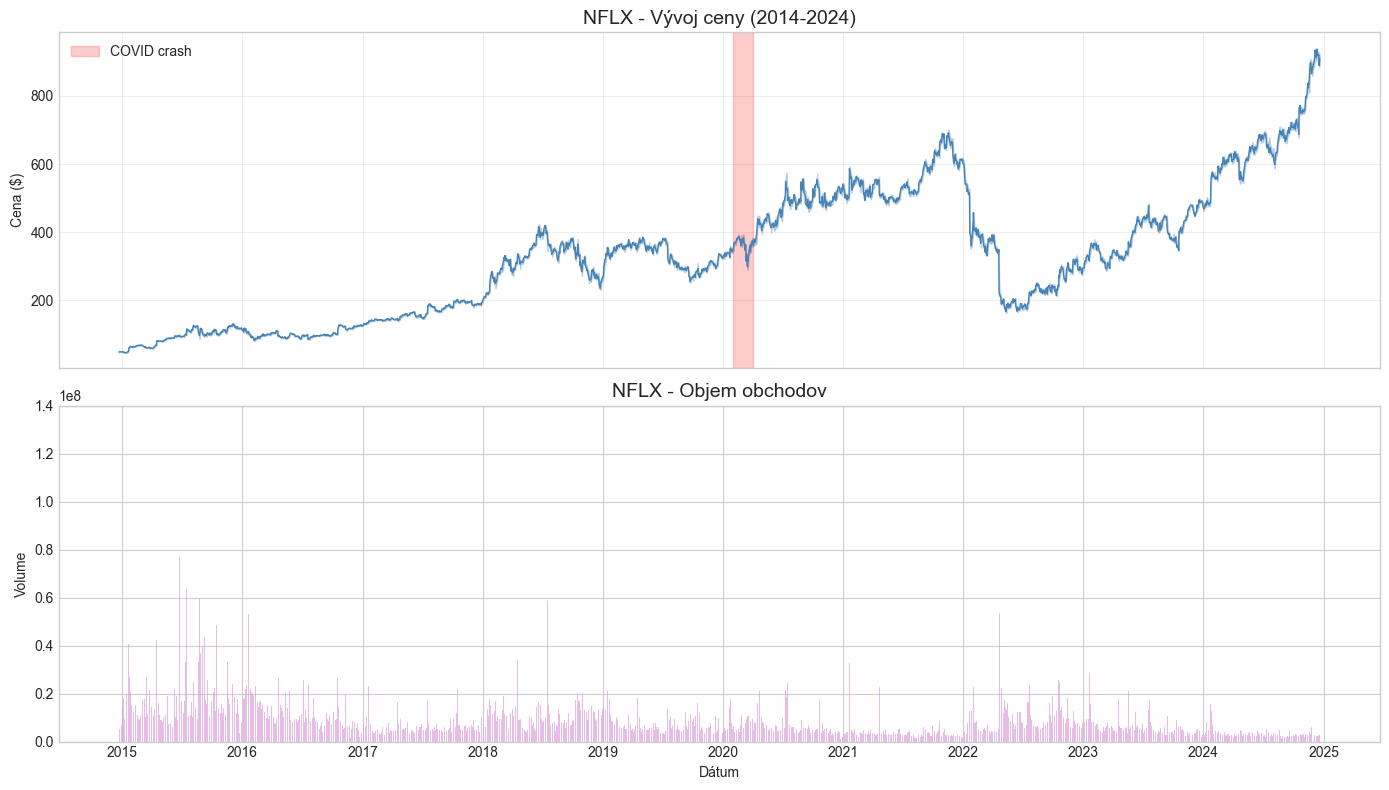


Cenový rozsah: $45.55 - $936.56
Celkový rast: 1790.0%


In [290]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Cena
axes[0].plot(df_stock['Date'], df_stock['Close'], color='steelblue', linewidth=1)
axes[0].fill_between(df_stock['Date'], df_stock['Low'], df_stock['High'], alpha=0.3, color='steelblue')
axes[0].set_title(f'{symbol} - Vývoj ceny (2014-2024)', fontsize=14)
axes[0].set_ylabel('Cena ($)')
axes[0].grid(True, alpha=0.3)

# Zvýraznenie COVID crashu
axes[0].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'), alpha=0.2, color='red', label='COVID crash')
axes[0].legend()

# Volume
axes[1].bar(df_stock['Date'], df_stock['Volume'], color='plum', alpha=0.7, width=1)
axes[1].set_title(f'{symbol} - Objem obchodov', fontsize=14)
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Dátum')

plt.tight_layout()
plt.show()

# Štatistiky
print(f"\nCenový rozsah: ${df_stock['Close'].min():.2f} - ${df_stock['Close'].max():.2f}")
print(f"Celkový rast: {((df_stock['Close'].iloc[-1] / df_stock['Close'].iloc[0]) - 1) * 100:.1f}%")

### Denné výnosy (returns)

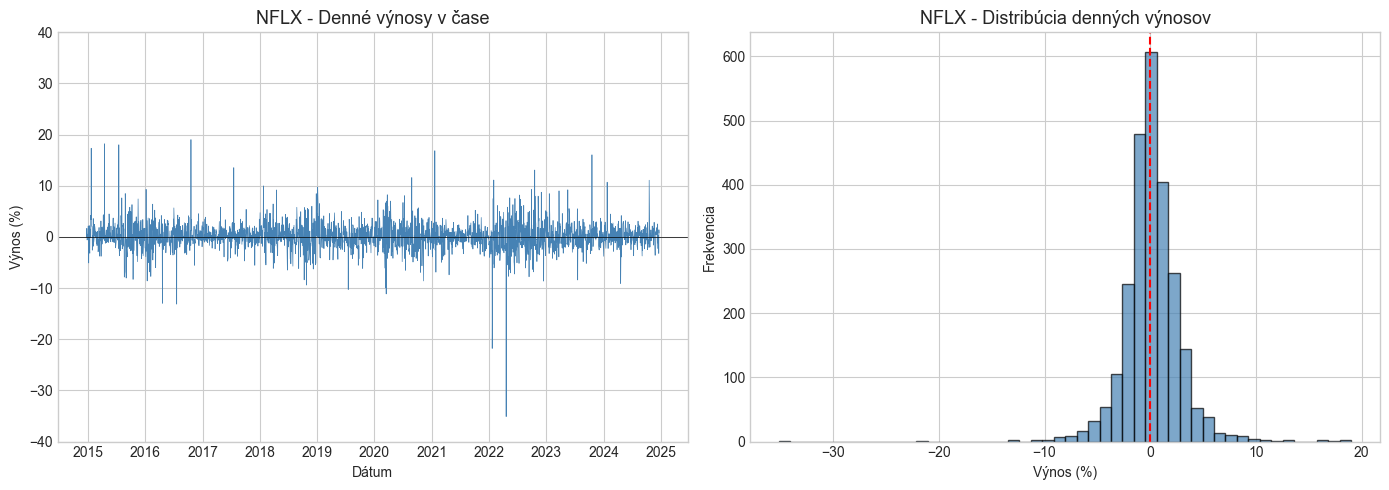


Priemerný denný výnos: 0.1551%
Štandardná odchýlka (volatilita): 2.75%
Najväčší denný rast: 19.03%
Najväčší denný prepad: -35.12%


In [291]:
df_stock['Daily_Return'] = df_stock['Close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Časový rad výnosov
axes[0].plot(df_stock['Date'], df_stock['Daily_Return'] * 100, color='steelblue', linewidth=0.5)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_title(f'{symbol} - Denné výnosy v čase', fontsize=13)
axes[0].set_xlabel('Dátum')
axes[0].set_ylabel('Výnos (%)')
axes[0].set_ylim(-40, 40)

# Histogram výnosov
axes[1].hist(df_stock['Daily_Return'].dropna() * 100, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title(f'{symbol} - Distribúcia denných výnosov', fontsize=13)
axes[1].set_xlabel('Výnos (%)')
axes[1].set_ylabel('Frekvencia')

plt.tight_layout()
plt.show()

print(f"\nPriemerný denný výnos: {df_stock['Daily_Return'].mean()*100:.4f}%")
print(f"Štandardná odchýlka (volatilita): {df_stock['Daily_Return'].std()*100:.2f}%")
print(f"Najväčší denný rast: {df_stock['Daily_Return'].max()*100:.2f}%")
print(f"Najväčší denný prepad: {df_stock['Daily_Return'].min()*100:.2f}%")

### Volatilita v čase (rolling std)
Volatilita je miera kolísavosti cien akcií. V tomto grafe používame 20-dňové kĺzavé okno na výpočet štandardnej odchýlky denných výnosov, čo nám poskytuje predstavu o tom, ako veľmi sa cena akcie mení v priebehu času.

Z grafu vyplýva, že volatilita bola výrazne zvýšená počas obdobia COVID-19 (február - jún 2020).

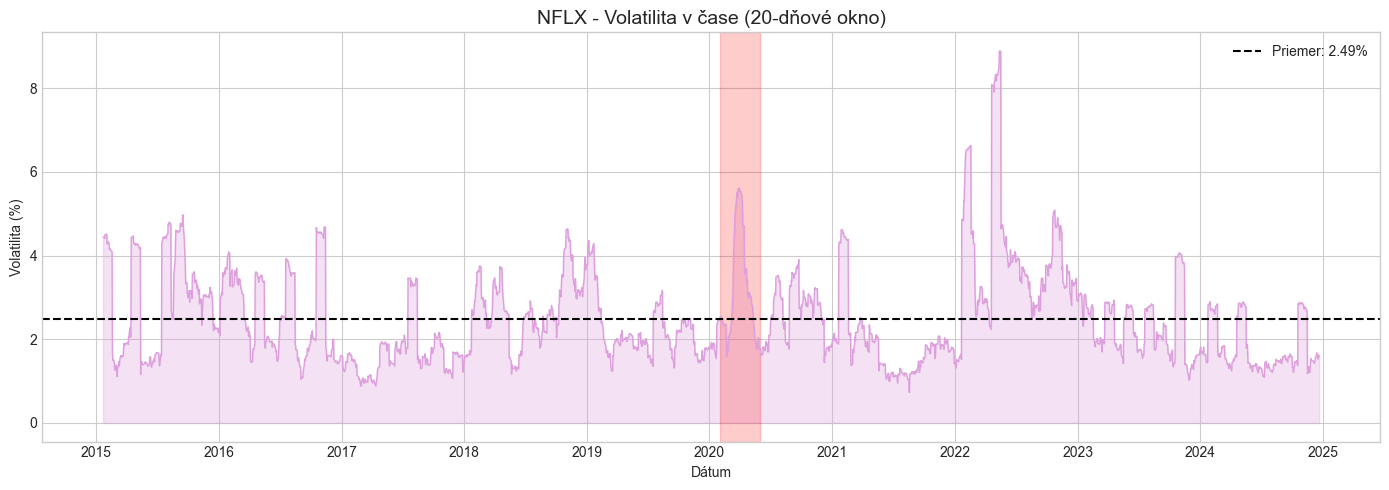


Top 5 dní s najvyššou volatilitou:
      Date  Volatility_20d
2022-05-16        8.890096
2022-05-13        8.886521
2022-05-17        8.859134
2022-05-12        8.561025
2022-05-11        8.445247


In [292]:
df_stock['Volatility_20d'] = df_stock['Daily_Return'].rolling(20).std() * 100

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_stock['Date'], df_stock['Volatility_20d'], color='plum', linewidth=1)
ax.axhline(y=df_stock['Volatility_20d'].mean(), color='black', linestyle='--',
           label=f'Priemer: {df_stock["Volatility_20d"].mean():.2f}%')
ax.fill_between(df_stock['Date'], 0, df_stock['Volatility_20d'], alpha=0.3, color='plum')
ax.set_title(f'{symbol} - Volatilita v čase (20-dňové okno)', fontsize=14)
ax.set_xlabel('Dátum')
ax.set_ylabel('Volatilita (%)')
ax.legend()

# Označenie vysokej volatility (COVID)
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'), alpha=0.2, color='red')

plt.tight_layout()
plt.show()

# Obdobia s najvyššou volatilitou
high_vol = df_stock.nlargest(5, 'Volatility_20d')[['Date', 'Volatility_20d']]
print("\nTop 5 dní s najvyššou volatilitou:")
print(high_vol.to_string(index=False))

### Sezónnosť - priemerné výnosy podľa mesiaca a dňa v týždni
Najlepsie mesiace pre NVDA: Máj, November, Február

Najhoršie mesiace pre NVDA: December, Apríl, September

Priemerny denny vynos podla dna v tyzdni vychadza na stvrtok a pondelok, njahorsie je na tom piatok.

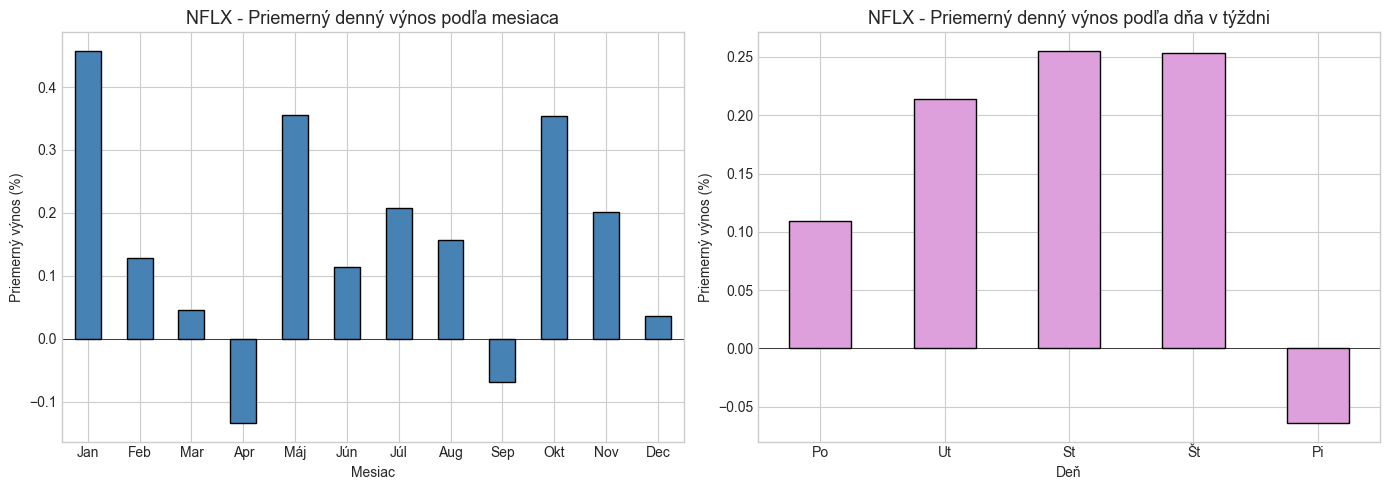

In [293]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Podľa mesiaca
df_stock['Month'] = df_stock['Date'].dt.month
monthly_returns = df_stock.groupby('Month')['Daily_Return'].mean() * 100
monthly_returns.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_title(f'{symbol} - Priemerný denný výnos podľa mesiaca', fontsize=13)
axes[0].set_xlabel('Mesiac')
axes[0].set_ylabel('Priemerný výnos (%)')
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'Máj', 'Jún',
                         'Júl', 'Aug', 'Sep', 'Okt', 'Nov', 'Dec'], rotation=0)

# Podľa dňa v týždni
df_stock['DayOfWeek'] = df_stock['Date'].dt.dayofweek
daily_returns = df_stock.groupby('DayOfWeek')['Daily_Return'].mean() * 100
daily_returns.plot(kind='bar', ax=axes[1], color='plum', edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title(f'{symbol} - Priemerný denný výnos podľa dňa v týždni', fontsize=13)
axes[1].set_xlabel('Deň')
axes[1].set_ylabel('Priemerný výnos (%)')
axes[1].set_xticklabels(['Po', 'Ut', 'St', 'Št', 'Pi'], rotation=0)

plt.tight_layout()
plt.show()

### Ročné výnosy

Najlepší rok: 2023 (245.9%)

Najhorší rok: 2022 (-51.5%)

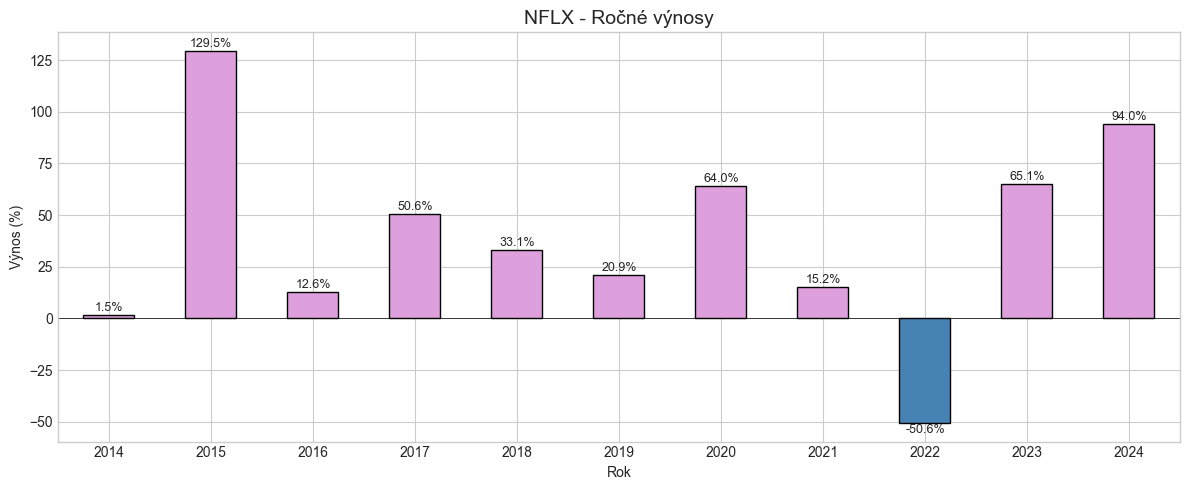


Najlepší rok: 2015 (129.5%)
Najhorší rok: 2022 (-50.6%)


In [294]:
df_stock['Year'] = df_stock['Date'].dt.year

yearly_performance = df_stock.groupby('Year')['Close'].apply(
    lambda x: (x.iloc[-1] / x.iloc[0] - 1) * 100
).sort_index()

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['plum' if x > 0 else 'steelblue' for x in yearly_performance]
yearly_performance.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title(f'{symbol} - Ročné výnosy', fontsize=14)
ax.set_xlabel('Rok')
ax.set_ylabel('Výnos (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, v in enumerate(yearly_performance):
    ax.text(i, v + (2 if v > 0 else -5), f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nNajlepší rok: {yearly_performance.idxmax()} ({yearly_performance.max():.1f}%)")
print(f"Najhorší rok: {yearly_performance.idxmin()} ({yearly_performance.min():.1f}%)")

## Vytvorenie features a target
Feature = informácia z minulosti, ktorú model použije na predikciu

Target = to čo chceme predikovať = ZAJTRAJŠÍ VÝNOS

In [317]:
# Zajtrajšia cena
df_stock['Target'] = df_stock['Close'].shift(-1)

# Včerajšia cena
df_stock['Close_lag1'] = df_stock['Close'].shift(1)

# Cena pred 5 dňami
df_stock['Close_lag5'] = df_stock['Close'].shift(5)

# Výnos za posledný deň
df_stock['Return_1d'] = df_stock['Close'].pct_change(1)

# Výnos za posledných 5 dní
df_stock['Return_5d'] = df_stock['Close'].pct_change(5)

# Priemer ceny za 20 dní
df_stock['MA_20'] = df_stock['Close'].rolling(20).mean()

# Pomer ceny k priemeru (je akcia nad/pod priemerom?)
df_stock['MA_20_ratio'] = df_stock['Close'] / df_stock['MA_20']

# Volatilita (ako veľmi sa cena hýbe)
df_stock['Volatility'] = df_stock['Return_1d'].rolling(20).std()

# Volume včera
df_stock['Volume_lag1'] = df_stock['Volume'].shift(1)

print(df_stock[['Date', 'Close', 'Close_lag1', 'Return_1d', 'MA_20', 'MA_20_ratio', 'Volatility', 'Volume_lag1']].tail())

           Date       Close  Close_lag1  Return_1d       MA_20  MA_20_ratio  \
2512 2024-12-16  921.080017  918.869995   0.002405  899.625494     1.023848   
2513 2024-12-17  919.130005  921.080017  -0.002117  903.229495     1.017604   
2514 2024-12-18  889.549988  919.130005  -0.032183  904.140994     0.983862   
2515 2024-12-19  902.039978  889.549988   0.014041  905.050494     0.996674   
2516 2024-12-20  909.049988  902.039978   0.007771  905.628995     1.003777   

      Volatility  Volume_lag1  
2512    0.016080    2485800.0  
2513    0.015271    2674900.0  
2514    0.016177    2459500.0  
2515    0.016162    2938200.0  
2516    0.015895    2815500.0  


In [318]:
df_clean = df_stock.dropna()
print(f"\nPo odstránení NaN: {len(df_clean)} riadkov")


Po odstránení NaN: 2496 riadkov


### Preprocessing

In [331]:
# Features a Target
feature_columns = ['Close', 'Close_lag1', 'Close_lag5', 'Return_1d', 'Return_5d',
                   'MA_20', 'MA_20_ratio', 'Volatility', 'Volume_lag1']

X = df_clean[feature_columns].values
y = df_clean['Target'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Cena range: ${y.min():.2f} - ${y.max():.2f}")

X shape: (2496, 9)
y shape: (2496,)
Cena range: $59.02 - $936.56


### Rozdelenie na train/test set

### Škálovanie dát

In [332]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

print(f"X_scaled range: {X_scaled.min():.3f} - {X_scaled.max():.3f}")
print(f"y_scaled range: {y_scaled.min():.3f} - {y_scaled.max():.3f}")

X_scaled range: 0.000 - 1.000
y_scaled range: 0.000 - 1.000


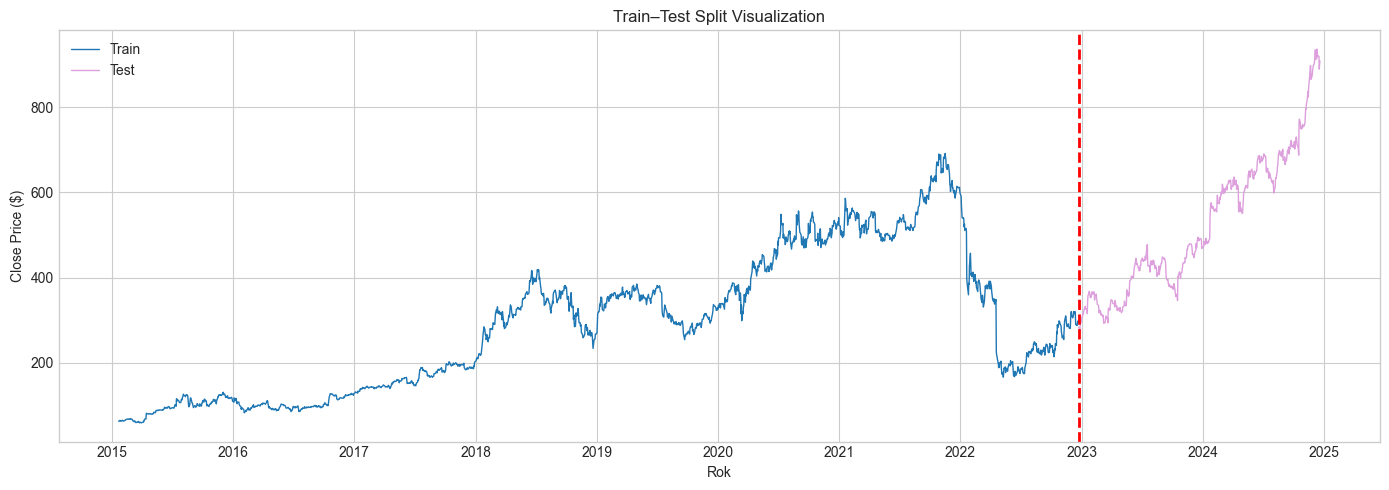

In [333]:
fig, ax = plt.subplots(figsize=(14, 5))

dates = df_clean['Date']
dates_train = dates.iloc[:split]
dates_test = dates.iloc[split:]

ax.plot(dates_train, y_train, label="Train", linewidth=1)
ax.plot(dates_test, y_test, color="plum",  label="Test", linewidth=1)

ax.axvline(dates_test.iloc[0], color="red", linestyle="--", linewidth=2)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=0)

ax.set_title("Train–Test Split Visualization")
ax.set_xlabel("Rok")
ax.set_ylabel("Close Price ($)")
ax.legend()
fig.tight_layout()
plt.show()

## Príprava pre NN

## 4.1b Zdôvodnenie výberu ML/DL metód vzhľadom na vybraný dataset pre 4.2

### Charakteristiky datasetu
| Vlastnosť | Hodnota                              |
|-----------|--------------------------------------|
| Typ úlohy | Regresia (predikcia spojitej hodnoty) |
| Target | Zajtrajší výnos akcie (%)            |
| Počet features | 8                                    |
| Typ dát | time series                          |

### Výber metódy

Na základe analýzy datasetu a charakteru úlohy (predikcia výnosov akcií z historických dát) sme sa rozhodla použiť **LSTM (Long Short-Term Memory)** neurónovú sieť.

### Prečo LSTM?

**1. Špecializovaná na časové rady**
LSTM je typ rekurentnej neurónovej siete navrhnutej špeciálne pre sekvenčné dáta. Akciové ceny sú time series - dnešná cena závisí od včerajšej, predvčerajšej, atď.

**2. Pamätá si dlhodobé závislosti**
Na rozdiel od klasických neurónových sietí, LSTM si dokáže "zapamätať" informácie z minulosti a využiť ich pri predikcii. Toto je kľúčové pre finančné dáta.

**3. Overená metóda pre finančné predikcie**
LSTM sa bežne používa v praxi na predikciu cien akcií, kryptomien a iných finančných inštrumentov.

### Porovnanie s inými metódami
- MLP - nevidi sekvenciu, len jednotlive body
- Linearna regresia - Príliš jednoduchá pre komplexné vzťahy

### Metriky hodnotenia

- **MAE** - priemerná absolútna chyba predikcie
- **RMSE** - penalizuje väčšie chyby viac
- **R²** - koľko variability dát model vysvetľuje

# 4.2 Modeling and evaluation
- (A-4b) Modeluje Vami tie vybrané charakteristiky pomocou vhodných ML/DL metód. 	Výsledok modelovania je najlepší model.
- (B-1b) Zhodnotíte Váš prístup a získaný výsledok

## 4.2a Machine Learning - LSTM model
LSTM potrebuje dáta v tvare: (samples, timesteps, features)

### Vytvorenie sekvencii
Vytvoríme sekvencie - model sa pozrie X dní dozadu a predikuje ďalší deň

In [337]:
# Sekvencie
LOOKBACK = 20

def create_sequences(X, y, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, LOOKBACK)

print(f"X_seq shape: {X_seq.shape}")  # (samples, lookback, features)
print(f"y_seq shape: {y_seq.shape}")

X_seq shape: (2476, 20, 9)
y_seq shape: (2476,)


In [338]:
split = int(len(X_seq) * 0.8)

X_train = X_seq[:split]
X_test = X_seq[split:]
y_train = y_seq[:split]
y_test = y_seq[split:]

print(f"Train: {len(X_train)}")
print(f"Test: {len(X_test)}")

Train: 1980
Test: 496


### LSTM model

In [308]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

In [340]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


X_train_t = torch.FloatTensor(X_train_seq).to(device)
y_train_t = torch.FloatTensor(y_train_seq).to(device)
X_test_t = torch.FloatTensor(X_test_seq).to(device)
y_test_t = torch.FloatTensor(y_test_seq).to(device)

# Train/Val split
val_split = int(len(X_train_t) * 0.8)
X_tr, X_val = X_train_t[:val_split], X_train_t[val_split:]
y_tr, y_val = y_train_t[:val_split], y_train_t[val_split:]

#  DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Batches: {len(train_loader)}")


Device: cpu
Batches: 63


In [341]:
# =============================================================
# 6. LSTM MODEL
# =============================================================

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=50, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, features)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # Použijeme posledný output
        out = self.fc(lstm_out[:, -1, :])
        return out.squeeze()

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size=50, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        rnn_out, h_n = self.rnn(x)
        out = self.fc(rnn_out[:, -1, :])
        return out.squeeze()

# Vytvorenie modelov
input_size = X_train.shape[2]  # počet features
model_lstm = LSTMModel(input_size, hidden_size=50, num_layers=2).to(device)
model_rnn = RNNModel(input_size, hidden_size=50, num_layers=2).to(device)

print(f"Input size: {input_size}")
print(f"LSTM params: {sum(p.numel() for p in model_lstm.parameters()):,}")
print(f"RNN params: {sum(p.numel() for p in model_rnn.parameters()):,}")

Input size: 9
LSTM params: 32,651
RNN params: 8,201


In [342]:
# =============================================================
# 7. TRÉNOVANIE
# =============================================================

def train_model(model, train_loader, X_test_t, y_test_t, epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'test_loss': []}

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Test loss
        model.eval()
        with torch.no_grad():
            test_pred = model(X_test_t)
            test_loss = criterion(test_pred, y_test_t).item()

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train: {train_loss:.6f}, Test: {test_loss:.6f}")

    return history

# Trénovanie LSTM
print("=== LSTM Training ===")
history_lstm = train_model(model_lstm, train_loader, X_test_t, y_test_t, epochs=100)

# Trénovanie RNN
print("\n=== RNN Training ===")
model_rnn = RNNModel(input_size, hidden_size=50, num_layers=2).to(device)
history_rnn = train_model(model_rnn, train_loader, X_test_t, y_test_t, epochs=100)

=== LSTM Training ===
Epoch 20/100 - Train: 0.000841, Test: 0.002014
Epoch 40/100 - Train: 0.000737, Test: 0.001140
Epoch 60/100 - Train: 0.000601, Test: 0.000910
Epoch 80/100 - Train: 0.000567, Test: 0.001228
Epoch 100/100 - Train: 0.000495, Test: 0.001191

=== RNN Training ===
Epoch 20/100 - Train: 0.000746, Test: 0.003346
Epoch 40/100 - Train: 0.001100, Test: 0.004032
Epoch 60/100 - Train: 0.000617, Test: 0.001710
Epoch 80/100 - Train: 0.000625, Test: 0.002463
Epoch 100/100 - Train: 0.000595, Test: 0.002860


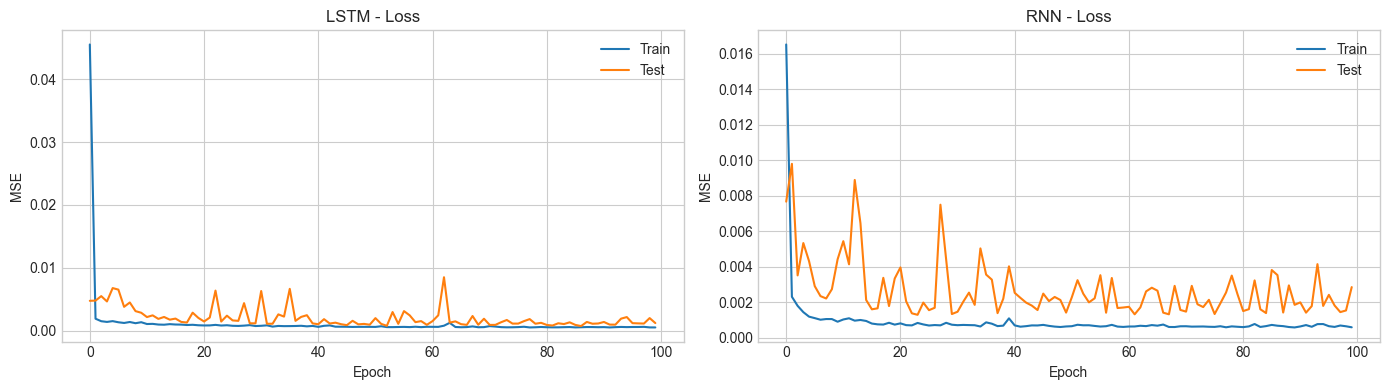

In [343]:
# =============================================================
# 8. GRAF TRÉNOVANIA
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_lstm['train_loss'], label='Train')
axes[0].plot(history_lstm['test_loss'], label='Test')
axes[0].set_title('LSTM - Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history_rnn['train_loss'], label='Train')
axes[1].plot(history_rnn['test_loss'], label='Test')
axes[1].set_title('RNN - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].legend()

plt.tight_layout()
plt.show()

In [327]:
# Predikcie
model_lstm.eval()
model_rnn.eval()

with torch.no_grad():
    pred_train_lstm_scaled = model_lstm(X_train_t).cpu().numpy().reshape(-1, 1)
    pred_train_rnn_scaled = model_rnn(X_train_t).cpu().numpy().reshape(-1, 1)
    pred_test_lstm_scaled = model_lstm(X_test_t).cpu().numpy().reshape(-1, 1)
    pred_test_rnn_scaled = model_rnn(X_test_t).cpu().numpy().reshape(-1, 1)

# Spätná transformácia - MinMaxScaler
pred_train_lstm = scaler_y.inverse_transform(pred_train_lstm_scaled).flatten()
pred_train_rnn = scaler_y.inverse_transform(pred_train_rnn_scaled).flatten()
pred_test_lstm = scaler_y.inverse_transform(pred_test_lstm_scaled).flatten()
pred_test_rnn = scaler_y.inverse_transform(pred_test_rnn_scaled).flatten()

actual_train = scaler_y.inverse_transform(y_train_seq.reshape(-1, 1)).flatten()
actual_test = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

print(f"Actual train: ${actual_train.min():.2f} - ${actual_train.max():.2f}")
print(f"Actual test: ${actual_test.min():.2f} - ${actual_test.max():.2f}")
print(f"LSTM test pred: ${pred_test_lstm.min():.2f} - ${pred_test_lstm.max():.2f}")

Actual train: $59.02 - $936.56
Actual test: $383.23 - $1276.20
LSTM test pred: $398.66 - $1092.14


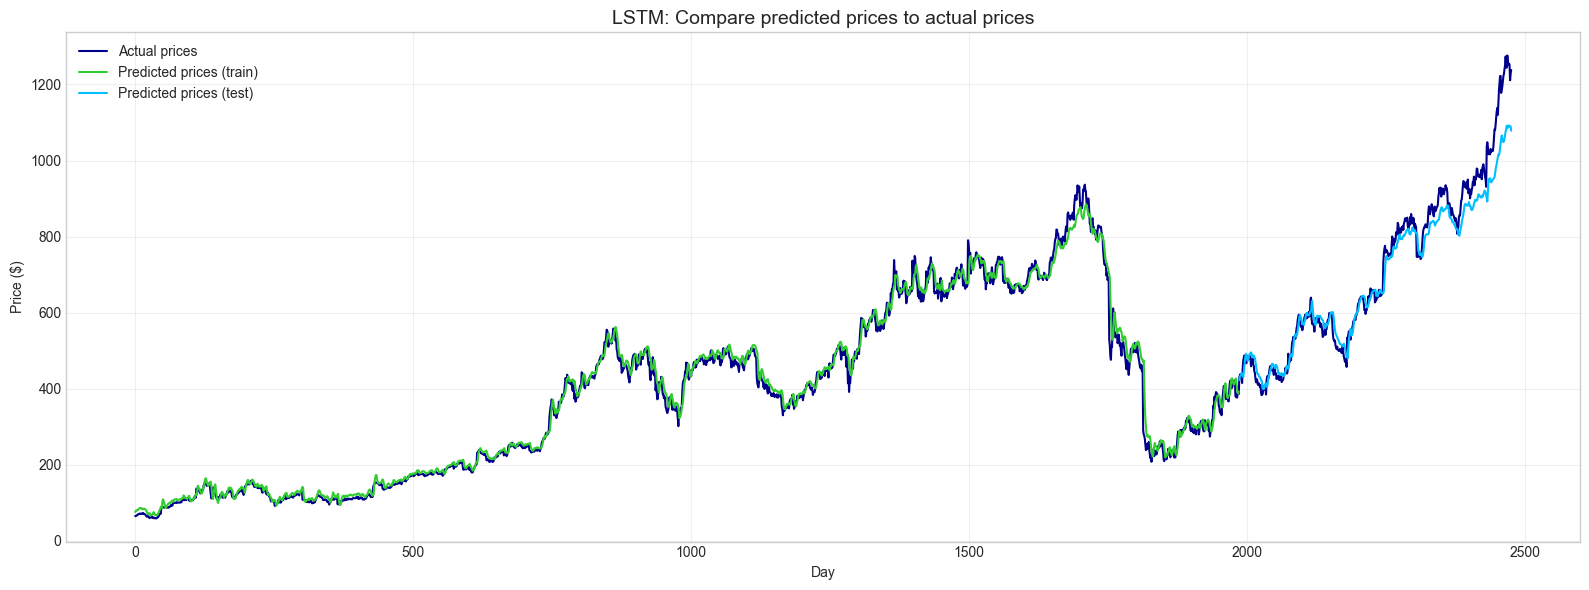

In [328]:
# Hlavný graf
all_actual = np.concatenate([actual_train, actual_test])

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(range(len(all_actual)), all_actual, label='Actual prices', color='darkblue', linewidth=1.5)
ax.plot(range(len(pred_train_lstm)), pred_train_lstm, label='Predicted prices (train)', color='limegreen', linewidth=1.5)
ax.plot(range(len(pred_train_lstm), len(pred_train_lstm) + len(pred_test_lstm)), pred_test_lstm,
        label='Predicted prices (test)', color='deepskyblue', linewidth=1.5)

ax.set_title('LSTM: Compare predicted prices to actual prices', fontsize=14)
ax.set_xlabel('Day')
ax.set_ylabel('Price ($)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [329]:
# Metriky
from sklearn.metrics import mean_absolute_error, r2_score

print("=== LSTM ===")
print(f"TRAIN - MAE: ${mean_absolute_error(actual_train, pred_train_lstm):.2f}, R²: {r2_score(actual_train, pred_train_lstm):.4f}")
print(f"TEST  - MAE: ${mean_absolute_error(actual_test, pred_test_lstm):.2f}, R²: {r2_score(actual_test, pred_test_lstm):.4f}")

print("\n=== RNN ===")
print(f"TRAIN - MAE: ${mean_absolute_error(actual_train, pred_train_rnn):.2f}, R²: {r2_score(actual_train, pred_train_rnn):.4f}")
print(f"TEST  - MAE: ${mean_absolute_error(actual_test, pred_test_rnn):.2f}, R²: {r2_score(actual_test, pred_test_rnn):.4f}")

=== LSTM ===
TRAIN - MAE: $14.15, R²: 0.9908
TEST  - MAE: $35.22, R²: 0.9449

=== RNN ===
TRAIN - MAE: $13.02, R²: 0.9916
TEST  - MAE: $43.06, R²: 0.9066


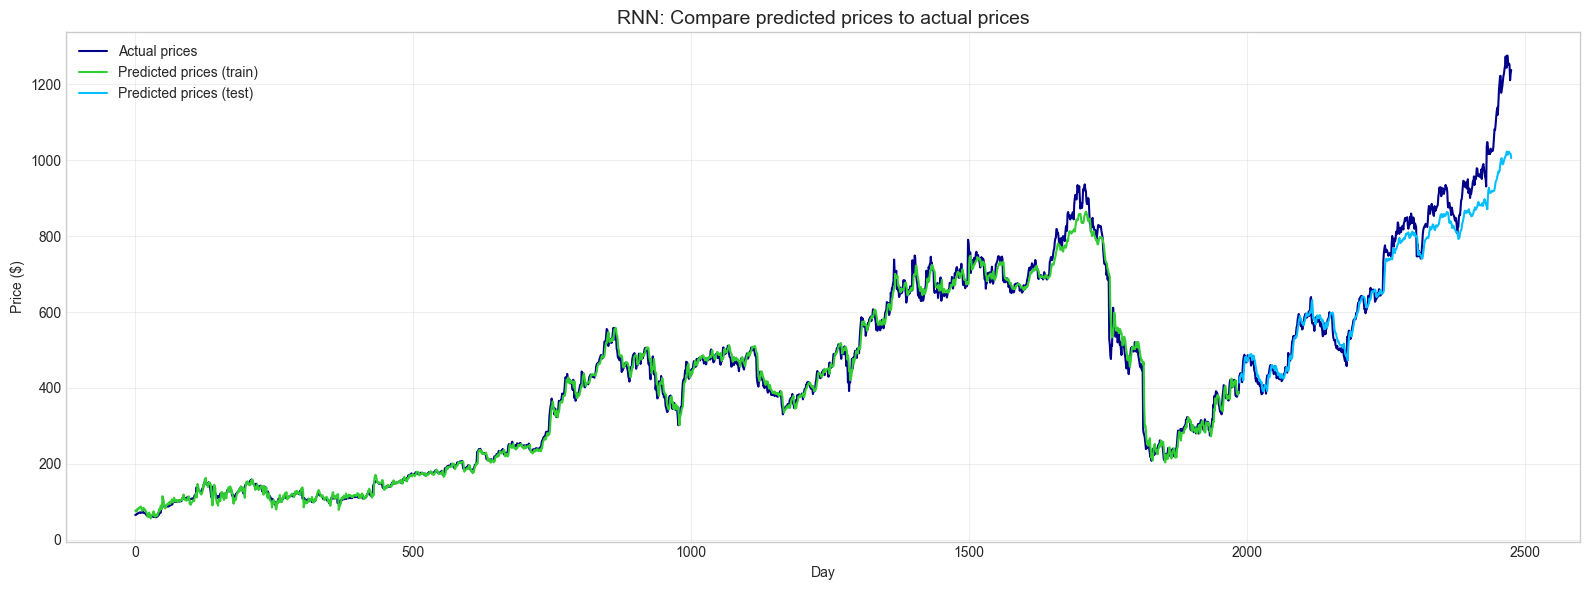

In [330]:
# RNN graf
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(range(len(all_actual)), all_actual, label='Actual prices', color='darkblue', linewidth=1.5)
ax.plot(range(len(pred_train_rnn)), pred_train_rnn, label='Predicted prices (train)', color='limegreen', linewidth=1.5)
ax.plot(range(len(pred_train_rnn), len(pred_train_rnn) + len(pred_test_rnn)), pred_test_rnn,
        label='Predicted prices (test)', color='deepskyblue', linewidth=1.5)

ax.set_title('RNN: Compare predicted prices to actual prices', fontsize=14)
ax.set_xlabel('Day')
ax.set_ylabel('Price ($)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()